In [61]:
import pandas as pd
from pathlib import Path

In [62]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/day7_clean_supply_data.csv"
OUTPUT_FILE = PROJECT_ROOT / "03_processed_data/day8_time_normalized_supply_data.csv"

df = pd.read_csv(INPUT_FILE)


In [67]:
print(df["procurement_date"].head(20))

0    2025-10-07
1    2025-04-12
2    2025-03-23
3    2025-02-19
4    2025-07-13
5    2025-01-24
6    2025-07-06
7    2025-11-22
8    2025-04-23
9    2025-10-18
10   2025-05-16
11   2025-04-23
12   2025-03-23
13   2025-10-11
14   2025-11-25
15   2025-09-14
16   2025-03-20
17   2025-09-08
18   2025-09-06
19   2025-11-07
Name: procurement_date, dtype: datetime64[ns]


In [65]:
df["procurement_date"] = pd.to_datetime(
    df["procurement_date"],
    format="mixed",
    dayfirst=True
)

In [68]:
df["procurement_year"] = df["procurement_date"].dt.year
df["procurement_month"] = df["procurement_date"].dt.month
df["procurement_day"] = df["procurement_date"].dt.day
df["procurement_weekday"] = df["procurement_date"].dt.day_name()

In [69]:
invalid_dates = df[df["procurement_date"].isnull()]

print("Invalid date records:", len(invalid_dates))

Invalid date records: 0


In [70]:
invalid_dates.to_csv(
    PROJECT_ROOT / "03_processed_data/invalid_date_records.csv",
    index=False
)

In [71]:
monthly_procurement = df.groupby(
    "procurement_month"
)["quantity"].sum()

monthly_procurement.to_csv(
    PROJECT_ROOT / "03_processed_data/monthly_procurement_volume.csv"
)

In [72]:
supplier_month_activity = df.groupby(
    ["vendor_name","procurement_month"]
)["quantity"].sum().reset_index()

supplier_month_activity.to_csv(
    PROJECT_ROOT / "03_processed_data/supplier_month_activity.csv",
    index=False
)

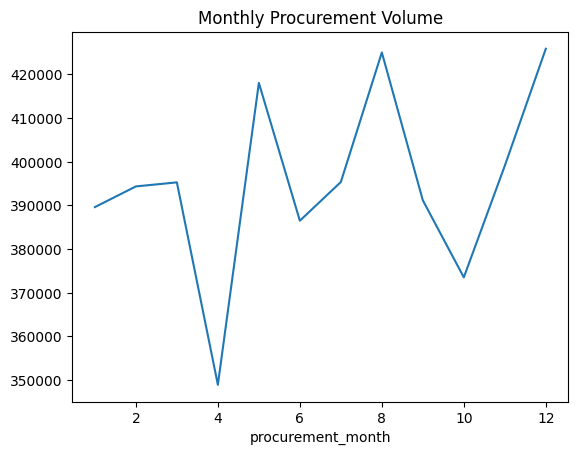

In [73]:
import matplotlib.pyplot as plt

plt.figure()

monthly_procurement.plot(kind="line")

plt.title("Monthly Procurement Volume")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/monthly_procurement_trend.png"
)
plt.show()
plt.close()

In [74]:
df.to_csv(OUTPUT_FILE, index=False)

print("Day 8 processing completed")

Day 8 processing completed
